In [1]:
import warnings

from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")
import torch

import pandas as pd
import numpy as np
import scanpy as sc
import os
import yaml
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ['R_HOME'] = 'D:/software/R/R-4.3.2'
os.environ['R_USER'] = 'D:/software/anaconda/anaconda3/envs/pt20cu118/Lib/site-packages/rpy2'
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.decomposition import PCA

# %%
import MACWT as TOOLS

In [2]:
# %%
with open('../Config/STARmap.yaml', 'r', encoding='utf-8') as f:
    config = yaml.load(f.read(), Loader=yaml.FullLoader)

In [3]:
adata = sc.read_h5ad(r"D:\project\datasets\data\STARmap_mouse_visual_cortex\STARmap_20180505_BY3_1k.h5ad")
adata.var_names_make_unique()

adata.obs['layer_guess'] = adata.obs['label']

edge_index = TOOLS.graph_construction(adata, config['data']['k_cutoff'])

adata.layers['count'] = adata.X
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=config['data']['top_genes'])
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [4]:
num_clusters = 7
# %%
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
net = TOOLS.SC_pipeline(adata, edge_index=edge_index, num_clusters=num_clusters, device=device, config=config,
                 imputation=False)
# %%
net.trian()
# %%
enc_rep, recon = net.process()
adata.obsm['latent'] = enc_rep

Epoch 299 total loss=1.130 recon loss=1.120 mean loss=0.400 tri loss=1.376: 100%|██████████| 300/300 [00:07<00:00, 37.91it/s]


In [5]:
clusType = 'mclust'
# %%
adata.obs[clusType] = TOOLS.clustering(z=enc_rep, n_clust=num_clusters, num_seed=1, method=clusType)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.0.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


In [6]:
ARI, ACC, DIS = TOOLS.get_metrics(adata, 'layer_guess', clusType)
print(f"ARI: {round(ARI, 4)} ACC: {round(ACC, 4)} DIS: {round(DIS, 4)}")

ARI: 0.7048 ACC: 0.752 DIS: 0.0495


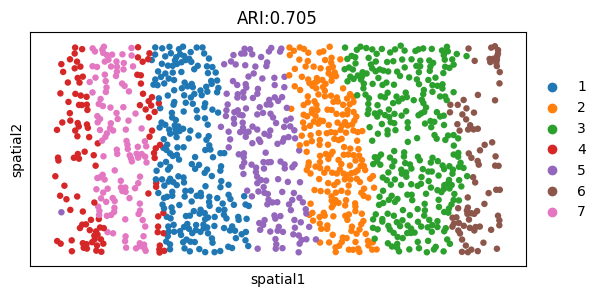

In [7]:
sc.pl.spatial(adata, color=['mclust'],
              title='ARI:' + str(round(ARI, 3)), show=True, spot_size=200, save=False)

In [8]:
adata

AnnData object with n_obs × n_vars = 1207 × 1016
    obs: 'Total_counts', 'X', 'Y', 'label', 'layer_guess', 'mclust'
    var: 'n_cells', 'n_counts', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'mean', 'std'
    uns: 'label_colors', 'hvg', 'mclust_colors'
    obsm: 'spatial', 'X_pca', 'latent', 'ReX'
    layers: 'count'